In [38]:
!pip install -q ultralytics opencv-python matplotlib

In [39]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [40]:
from google.colab import files

uploaded = files.upload()

Saving best.pt to best (1).pt


In [59]:
import os

print(os.path.exists("/content/best.pt"))

True


In [60]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [61]:
image_url = "https://ultralytics.com/assets/brain-tumor-sample.jpg"

In [62]:
import requests

response = requests.get(image_url)

with open("brain_tumor.jpg", "wb") as f:
    f.write(response.content)

In [63]:
results = model.predict(
    "brain_tumor.jpg",
    conf=0.25
)

result = results[0]


image 1/1 /content/brain_tumor.jpg: 640x640 1 negative, 1 positive, 180.1ms
Speed: 5.7ms preprocess, 180.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [64]:
tumor_detected = False

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"Class: {class_name}, Confidence: {confidence:.4f}")

    if class_name == "positive":
        tumor_detected = True

if tumor_detected:
    print("Tumor: DETECTED")
else:
    print("Tumor: NOT DETECTED")

Class: positive, Confidence: 0.3351
Class: negative, Confidence: 0.3131
Tumor: DETECTED


In [65]:
for i, layer in enumerate(model.model.model):
    print(i, layer)

0 Conv(
  (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
1 Conv(
  (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
2 C3k2(
  (cv1): Conv(
    (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [66]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activation
        )

        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [67]:
for i, layer in enumerate(model.model.model):
    print(i, type(layer).__name__)

0 Conv
1 Conv
2 C3k2
3 Conv
4 C3k2
5 Conv
6 C3k2
7 Conv
8 C3k2
9 SPPF
10 C2PSA
11 Upsample
12 Concat
13 C3k2
14 Upsample
15 Concat
16 C3k2
17 Conv
18 Concat
19 C3k2
20 Conv
21 Concat
22 C3k2
23 Detect


In [69]:
target_layer = model.model.model[-2]

In [70]:
gradcam = GradCAM(
    model.model,
    target_layer
)

In [71]:
results = model.predict(
    "brain_tumor.jpg",
    conf=0.25,
    verbose=False
)

result = results[0]

positive_box = None
positive_conf = 0

for box in result.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])

    class_name = model.names[cls]

    print(f"Class: {class_name}, Confidence: {conf:.4f}")

    if class_name == "positive" and conf > positive_conf:
        positive_conf = conf
        positive_box = box

if positive_box is None:
    print("No tumor detected.")
else:
    print(f"Tumor detected! Confidence: {positive_conf:.4f}")

Class: positive, Confidence: 0.3351
Class: negative, Confidence: 0.3131
Tumor detected! Confidence: 0.3351


In [72]:
if positive_box is not None:

    x1, y1, x2, y2 = positive_box.xyxy[0].cpu().numpy()

    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

    print("Tumor bounding box:")
    print("x1:", x1)
    print("y1:", y1)
    print("x2:", x2)
    print("y2:", y2)

Tumor bounding box:
x1: 151
y1: 124
x2: 166
y2: 135


In [73]:
from PIL import Image

image = Image.open("brain_tumor.jpg").convert("RGB")

img = np.array(image)

img_resized = cv2.resize(img, (640, 640))

img_tensor = torch.from_numpy(
    img_resized
).permute(2, 0, 1).float() / 255.0

img_tensor = img_tensor.unsqueeze(0)

device = next(model.model.parameters()).device

img_tensor = img_tensor.to(device)
img_tensor.requires_grad_(True)

gradcam.activations = None
gradcam.gradients = None

model.model.eval()

output = model.model(img_tensor)

print("Forward pass completed.")
print("Output type:", type(output))

if isinstance(output, (tuple, list)):
    print("Number of outputs:", len(output))
    for i, item in enumerate(output):
        if hasattr(item, "shape"):
            print(f"Output {i} shape:", item.shape)
else:
    print("Output shape:", output.shape)

Forward pass completed.
Output type: <class 'tuple'>
Number of outputs: 2
Output 0 shape: torch.Size([1, 6, 8400])


In [74]:
model.model.zero_grad()

if isinstance(output, (tuple, list)):
    output_tensor = output[0]
else:
    output_tensor = output

print("Output tensor shape:", output_tensor.shape)

if output_tensor.ndim != 3:
    raise RuntimeError(
        f"Unexpected YOLO output shape: {output_tensor.shape}"
    )

if output_tensor.shape[1] <= 10:
    class_scores = output_tensor[:, 4:, :]
else:
    class_scores = output_tensor[:, :, 4:]

print("Class score shape:", class_scores.shape)

positive_score = class_scores[:, 1, :].max()

print("Positive-class Grad-CAM score:", float(positive_score))

positive_score.backward()

print("Backward pass completed.")

if gradcam.gradients is None:
    raise RuntimeError("Gradients were not captured.")

print("Gradients captured successfully.")

Output tensor shape: torch.Size([1, 6, 8400])
Class score shape: torch.Size([1, 2, 8400])
Positive-class Grad-CAM score: 0.33505353331565857
Backward pass completed.
Gradients captured successfully.


In [75]:
activations = gradcam.activations
gradients = gradcam.gradients

if activations is None or gradients is None:
    raise RuntimeError("Grad-CAM activations or gradients are missing.")

weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1)

cam = torch.relu(cam)

cam = cam.squeeze().detach().cpu().numpy()

cam = cv2.resize(
    cam,
    (img.shape[1], img.shape[0])
)

cam -= cam.min()

if cam.max() > 0:
    cam /= cam.max()

print("Grad-CAM heatmap generated.")

Grad-CAM heatmap generated.


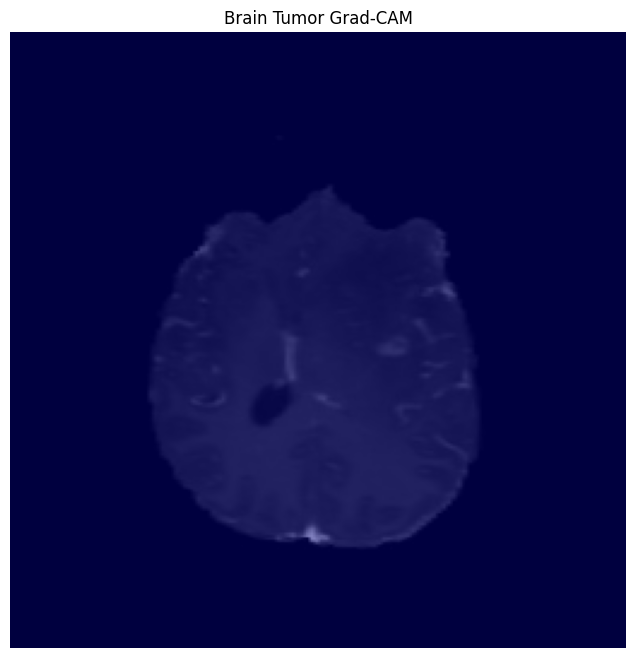

In [76]:
plt.figure(figsize=(8, 8))

plt.imshow(img)

plt.imshow(
    cam,
    cmap="jet",
    alpha=0.5
)

plt.axis("off")
plt.title("Brain Tumor Grad-CAM")

plt.show()

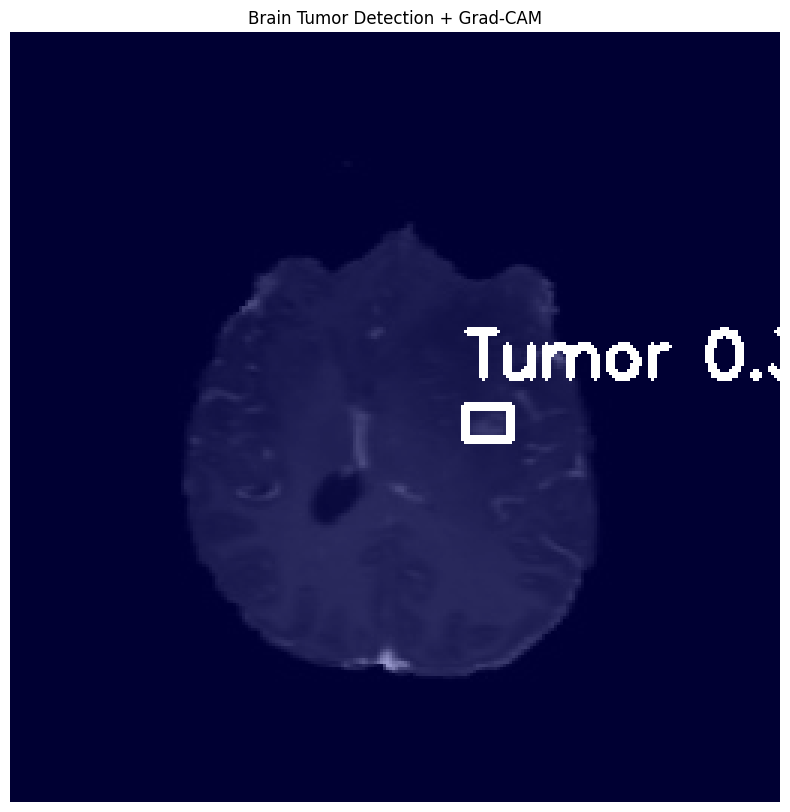

In [77]:
overlay = img.copy()

heatmap = np.uint8(255 * cam)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap = cv2.cvtColor(
    heatmap,
    cv2.COLOR_BGR2RGB
)

overlay = cv2.addWeighted(
    img,
    0.6,
    heatmap,
    0.4,
    0
)

if positive_box is not None:

    cv2.rectangle(
        overlay,
        (x1, y1),
        (x2, y2),
        (255, 255, 255),
        2
    )

    cv2.putText(
        overlay,
        f"Tumor {positive_conf:.2f}",
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

plt.figure(figsize=(10, 10))

plt.imshow(overlay)

plt.axis("off")

plt.title("Brain Tumor Detection + Grad-CAM")

plt.show()